<a href="https://colab.research.google.com/github/Anyajain05/Machine-learning/blob/main/Copy_of_CI1_Image_Classification_using_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial : Covid 19 Prediction using Artificial Neural Networks

Dataset: [Covid 19 Chest X-ray dataset](https://www.kaggle.com/tawsifurrahman/covid19-radiography-database)


A team of researchers from Qatar University, Doha, Qatar, and the University of Dhaka, Bangladesh along with their collaborators from Pakistan and Malaysia in collaboration with medical doctors have created a database of chest X-ray images for COVID-19 positive cases along with Normal and Viral Pneumonia images. This COVID-19, normal, and other lung infection dataset is released in stages. In the first release, we have released 219 COVID-19, 1341 normal, and 1345 viral pneumonia chest X-ray (CXR) images. In the first update, we have increased the COVID-19 class to 1200 CXR images. In the 2nd update, we have increased the database to 3616 COVID-19 positive cases along with 10,192 Normal, 6012 Lung Opacity (Non-COVID lung infection), and 1345 Viral Pneumonia images. We will continue to update this database as soon as we have new x-ray images for COVID-19 pneumonia patients.



**1. Mount the Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**2. Move to the place where data resides**

In [ ]:
%cd /content/drive/MyDrive/

/content/drive/MyDrive


In [ ]:
!ls

 1716145162402.jpg
 31_NSSAFE.gdoc
 31.pptx
 94ece878-d18f-457b-b51c-2a0fe06a6450.pdf
'AI anya (1).pptx'
'AI anya.pptx'
 CAF
 Classroom
'Class Wise Due Template.pdf'
'Colab Notebooks'
 covid_dataset.zip
'deliverable (1).mp4'
 deliverable.mp4
'DS L4,5,6 (1).gslides'
'DS L4,5,6.gslides'
'IMG20240301152201 (1).jpg'
'IMG20240301152201 (2).jpg'
 IMG20240301152201.jpg
'IMG_20250518_162434 (1).jpg'
 IMG_20250518_162434.jpg
 IMG_20250518_162550.jpg
 IMG_20250519_231023.jpg
 IMG_20250523_173551.jpg
 IMG_20250523_173622.jpg
 IMG_20251006_134949.jpg
 IMG-20251007-WA0043.jpg
 IMG_20251124_231137.jpg
 IMG-20260325-WA0020.jpg
 IMG-20260325-WA0023.jpg
'June13_trainingCourse2_AnyaJain_0827CI231023 (1).pdf'
 June13_trainingCourse2_AnyaJain_0827CI231023.pdf
'June13_trainingCourse_AnyaJain_0827CI231023 (1).pdf'
 June13_trainingCourse_AnyaJain_0827CI231023.pdf
 June17_onlineCourse2_AnyaJain_0827CI231023.pdf
 June17_onlineCourse_AnyaJain_0827CI231023.pdf
 Kaagaz_20240928_125101653571-1.jpg
 March25_onlineA

**3. Unziping the dataset**

In [ ]:
!pip install unzip

In [ ]:
!unzip covid_dataset.zip

Archive:  covid_dataset.zip
   creating: covid_dataset/
   creating: covid_dataset/COVID/
  inflating: covid_dataset/COVID/COVID-1.png  
  inflating: covid_dataset/COVID/COVID-10.png  
  inflating: covid_dataset/COVID/COVID-11.png  
  inflating: covid_dataset/COVID/COVID-12.png  
  inflating: covid_dataset/COVID/COVID-13.png  
  inflating: covid_dataset/COVID/COVID-14.png  
  inflating: covid_dataset/COVID/COVID-15.png  
  inflating: covid_dataset/COVID/COVID-16.png  
  inflating: covid_dataset/COVID/COVID-17.png  
  inflating: covid_dataset/COVID/COVID-18.png  
  inflating: covid_dataset/COVID/COVID-19.png  
  inflating: covid_dataset/COVID/COVID-2.png  
  inflating: covid_dataset/COVID/COVID-20.png  
  inflating: covid_dataset/COVID/COVID-21.png  
  inflating: covid_dataset/COVID/COVID-22.png  
  inflating: covid_dataset/COVID/COVID-23.png  
  inflating: covid_dataset/COVID/COVID-24.png  
  inflating: covid_dataset/COVID/COVID-25.png  
  inflating: covid_dataset/COVID/COVID-26.png  


**4. Install split folder python package**

https://pypi.org/project/split-folders/

In [ ]:
!pip install split_folders

**5. Splitting the data in training, testing and validation set**

In [ ]:
import splitfolders
splitfolders.ratio("covid_dataset", output="split", seed=1337, ratio=(.8, .1, .1), group_prefix=None)

Copying files: 150 files [00:01, 82.78 files/s]


**6. Loading the dataset with normalization in batches**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Normalize training and validation data in the range of 0 to 1
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Read the training sample and set the batch size
train_generator = train_datagen.flow_from_directory(
        'split/train/',
        target_size=(128, 128),
        batch_size=8,
        seed=100,
        class_mode='categorical')

# Read Validation data from directory and define target size with batch size
validation_generator = validation_datagen.flow_from_directory(
        'split/val/',
        target_size=(128, 128),
        batch_size=8,
        class_mode='categorical',
        seed=1000,
        shuffle=False)

test_generator = test_datagen.flow_from_directory(
        'split/test/',
        target_size=(128, 128),
        batch_size=8,
        seed=500,
        class_mode='categorical',
        shuffle=False)

Found 120 images belonging to 3 classes.
Found 15 images belonging to 3 classes.
Found 15 images belonging to 3 classes.


**7. Model Building**

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model

# Load the pre-trained MobileNetV2 model without the top (classification) layer
base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')

# Freeze the base model to prevent its weights from being updated during training
base_model.trainable = False

# Create a new model on top of the pre-trained base
inputs = keras.Input(shape=(128, 128, 3))
x = base_model(inputs, training=False) # Apply the base model in inference mode
x = layers.GlobalAveragePooling2D()(x) # Global average pooling layer
x = layers.Dropout(0.5)(x) # Increased dropout rate for regularization
outputs = layers.Dense(3, activation='softmax')(x) # Output layer with 3 classes

model = Model(inputs, outputs)

model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**8. Model Compilation and Training**

In [ ]:
from tensorflow.keras.optimizers import Adam

adam = Adam(learning_rate=0.0001)
# We are going to use accuracy metrics and cross entropy loss as performance parameters
model.compile(adam, loss='categorical_crossentropy', metrics=['accuracy'])  # Use 'accuracy'
# Train the model
history = model.fit(train_generator,
      steps_per_epoch=int(train_generator.samples / train_generator.batch_size),  # Convert to int
      epochs=100,
      validation_data=validation_generator,
      validation_steps=int(validation_generator.samples / validation_generator.batch_size),  # Convert to int
      verbose=1)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 423ms/step - accuracy: 0.2917 - loss: 1.6250 - val_accuracy: 0.5000 - val_loss: 0.8934
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.3083 - loss: 1.4945 - val_accuracy: 0.6250 - val_loss: 0.8992
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 171ms/step - accuracy: 0.2833 - loss: 1.4921 - val_accuracy: 0.6250 - val_loss: 0.8700
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.3250 - loss: 1.2922 - val_accuracy: 0.6250 - val_loss: 0.8419
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.3833 - loss: 1.2470 - val_accuracy: 0.6250 - val_loss: 0.8741
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.2917 - loss: 1.3154 - val_accuracy: 0.6250 - val_loss: 0.8449
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.3833 - loss: 1.3183 - val_accuracy: 0.6250 - val_loss: 0.8133
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.3500 - loss: 1.2308 - val_accuracy

### 8.1 Fine-tuning the Model

After training the classifier on top of the frozen base model, we can fine-tune the entire model (or part of it) by unfreezing some layers of the base model and retraining with a very low learning rate. This allows the model to adapt the pre-trained weights to the specific features of our dataset.

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

# Get the MobileNetV2 layer from the composite model. It is typically at index 1.
base_model_layer_in_composite = model.layers[1]

# Set the entire base model layer within the composite model to trainable.
# This ensures the base model's internal layers can be selectively unfrozen.
base_model_layer_in_composite.trainable = True

# Define how many layers from the end of the base MobileNetV2 we want to fine-tune.
fine_tune_at = -10

# Freeze all layers *before* the `fine_tune_at` index in the embedded base model.
# These layers will remain frozen during fine-tuning.
for layer in base_model_layer_in_composite.layers[:fine_tune_at]:
    layer.trainable = False

# For the layers from `fine_tune_at` onwards, ensure they are trainable,
# but keep BatchNormalization layers frozen as they can learn noisy statistics
# on small datasets.
for layer in base_model_layer_in_composite.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False # Keep BN layers frozen
    else:
        layer.trainable = True # Ensure other layers in the fine-tuning range are trainable

# Recompile the model with a very low learning rate for fine-tuning.
# This step is essential for the changes in trainable status to take effect in the model's graph.
model.compile(optimizer=Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 729,283 (2.78 MB)

 Non-trainable params: 1,532,544 (5.85 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping callback
early_stopping_callback = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=10,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

# Continue training (fine-tuning)
history_fine_tune = model.fit(train_generator,
                              steps_per_epoch=int(train_generator.samples / train_generator.batch_size),
                              epochs=100, # Increased epochs, but EarlyStopping will manage when to stop
                              validation_data=validation_generator,
                              validation_steps=int(validation_generator.samples / validation_generator.batch_size),
                              callbacks=[early_stopping_callback], # Add the callback here
                              verbose=1)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 497ms/step - accuracy: 0.7833 - loss: 0.4997 - val_accuracy: 0.7500 - val_loss: 0.5493
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.8083 - loss: 0.4456 - val_accuracy: 0.7500 - val_loss: 0.5616
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.8417 - loss: 0.3683 - val_accuracy: 0.7500 - val_loss: 0.4263
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.8167 - loss: 0.4303 - val_accuracy: 0.7500 - val_loss: 0.5132
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.8667 - loss: 0.3707 - val_accuracy: 0.7500 - val_loss: 0.4909
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.8833 - loss: 0.3393 - val_accuracy: 0.7500 - val_loss: 0.4652
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.8083 - loss: 0.4211 - val_accuracy: 0.7500 - val_loss: 0.4965
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.8250 - loss: 0.4449 - val_accuracy: 

**9. Model saving**

In [ ]:
model.save('covid_classification.h5')

**10. Model loading**

In [ ]:
from tensorflow.keras import models
model = models.load_model('covid_classification.h5')

**11. Model weights saving**

In [ ]:
model.save_weights('covid_classification_weights.weights.h5')

**12. Model weights loading**

In [ ]:
model.load_weights('covid_classification_weights.weights.h5')

**13. Plotting accuracy and loss graph for training and validation dataset**

### 13.1 Plotting accuracy and loss graph after Fine-tuning

In [ ]:
train_acc = history.history['accuracy'] # Change 'acc' to 'accuracy'
val_acc = history.history['val_accuracy'] # Change 'val_acc' to 'val_accuracy'
train_loss = history.history['loss']
val_loss = history.history['val_loss']

In [ ]:
# Concatenate the histories for plotting
acc = history.history['accuracy'] + history_fine_tune.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine_tune.history['val_accuracy']

loss = history.history['loss'] + history_fine_tune.history['loss']
val_loss = history.history['val_loss'] + history_fine_tune.history['val_loss']

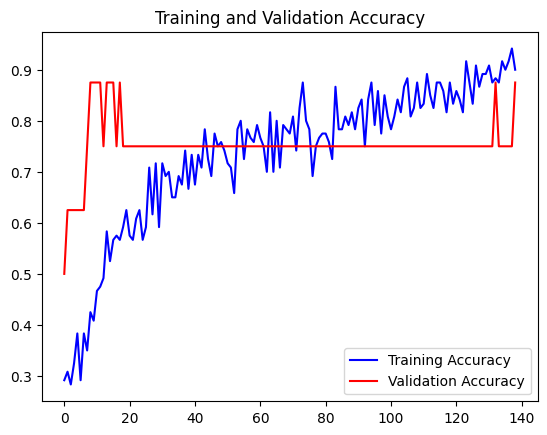

<Figure size 640x480 with 0 Axes>

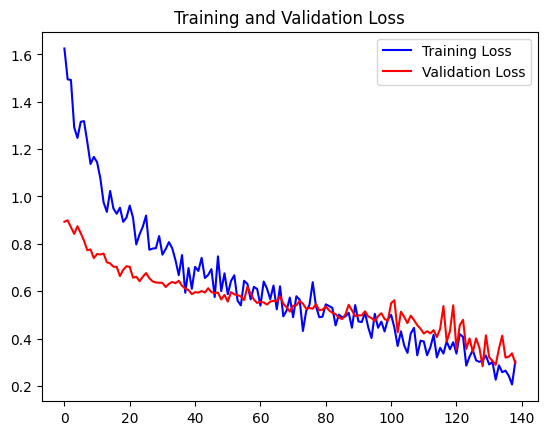

In [ ]:
import matplotlib.pyplot as plt
epochs = range(len(acc)) # Use the length of the concatenated accuracy list
plt.plot(epochs, acc, 'b', label='Training Accuracy') # Use the concatenated training accuracy
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.figure()
plt.show()

plt.plot(epochs, loss, 'b', label='Training Loss') # Use the concatenated training loss
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

**14. Evaluate model performance on test dataset**

### 14.1 Evaluate model performance on test dataset after Fine-tuning

In [ ]:
test_output = model.evaluate(
    test_generator,
    steps=int(test_generator.samples / test_generator.batch_size),  # Convert steps to an integer
    verbose=1
)
print(test_output)
print(model.metrics_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.7500 - loss: 0.3755
[0.3754540979862213, 0.75]
['loss', 'compile_metrics']


In [ ]:
test_output_fine_tune = model.evaluate(
    test_generator,
    steps=int(test_generator.samples / test_generator.batch_size),
    verbose=1
)
print(test_output_fine_tune)
print(model.metrics_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7500 - loss: 0.3755
[0.3754540979862213, 0.75]
['loss', 'compile_metrics']


References:

1. https://pypi.org/project/split-folders/
2. https://keras.io/